# 🧠 Section 08. U-Net 학습 파이프라인
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- DoubleConv 블록의 역할을 이해하고 직접 구현한다
- U-Net의 인코더-디코더와 Skip Connection을 단계별로 구현한다
- Dice Loss를 구현하고 CrossEntropy Loss와 성능을 비교한다
- mIoU로 학습 결과를 평가하고 GT vs 예측 마스크를 시각화한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | 합성 Segmentation 데이터 (Section 07 연속) |
| 크기 | NumPy 직접 생성 |
| 클래스 | 3개 (배경, 원형, 사각형) |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정
```bash
conda env create -f environment.yml
conda activate cnn-course
jupyter lab
```

In [1]:
# ⚙️ 환경 설정
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt, numpy as np, random
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device} | PyTorch: {torch.__version__}")

✅ Device: cpu | PyTorch: 2.11.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


---
## 실습 3. Dice Loss — 클래스 불균형에 강건한 손실

### 📖 CrossEntropy Loss만 쓰면 어떤 문제가 생기나?

세그멘테이션에서는 클래스 불균형이 흔합니다.  
이 합성 데이터에서도 배경(클래스 0)이 전체 픽셀의 약 60%를 차지합니다.

> ⚠️ **함정**: "모든 픽셀을 배경으로 예측"해도 약 60% 정확도가 나옵니다.  
> CrossEntropy Loss만 쓰면 모델이 이 "게으른 답"을 선택할 수 있습니다.

### 📖 Dice Loss가 이를 해결하는 방법

```
Dice = 2|예측 ∩ 정답| / (|예측| + |정답|)
```

Dice는 **실제로 탐지한 비율**에 집중합니다.  
"모두 배경"이라고 하면 원형·사각형 클래스의 Dice가 0이 되어 Loss가 매우 커집니다.

> 💡 **핵심 직관**  
> CrossEntropy: "몇 개나 맞혔는가" (다수 클래스에 유리)  
> Dice Loss: "얼마나 잘 겹치는가" (소수 클래스도 공정하게)  
> 실무에서는 `CE + Dice` 결합이 표준입니다.

In [3]:
# Section 07 데이터 생성 함수 (재사용)
def generate_seg_sample(img_size=128, n_shapes=3, seed=None):
    if seed is not None: np.random.seed(seed); random.seed(seed)
    img  = np.ones((img_size,img_size,3), dtype=np.uint8)*40
    mask = np.zeros((img_size,img_size), dtype=np.int64)
    for _ in range(n_shapes):
        shape = random.choice(['circle','rect'])
        cx,cy = np.random.randint(20,img_size-20,2)
        r = np.random.randint(10,28)
        color = tuple(np.random.randint(120,255,3).tolist())
        Y,X = np.ogrid[:img_size,:img_size]
        if shape=='circle':
            reg=(X-cx)**2+(Y-cy)**2<r**2; img[reg]=color; mask[reg]=1
        else:
            x1,y1=max(0,cx-r),max(0,cy-r); x2,y2=min(img_size,cx+r),min(img_size,cy+r)
            img[y1:y2,x1:x2]=color; mask[y1:y2,x1:x2]=2
    return img, mask

class SyntheticSegDataset(Dataset):
    def __init__(self,size=300,img_size=128): self.size=size; self.img_size=img_size
    def __len__(self): return self.size
    def __getitem__(self,idx):
        img,mask=generate_seg_sample(self.img_size,3,seed=idx)
        return torch.from_numpy(img).float().permute(2,0,1)/255.0, torch.from_numpy(mask).long()

train_ds=SyntheticSegDataset(300); val_ds=SyntheticSegDataset(60)
train_dl=DataLoader(train_ds,8,shuffle=True); val_dl=DataLoader(val_ds,8)
print(f"Train: {len(train_ds)} / Val: {len(val_ds)}")

Train: 300 / Val: 60


---
## 실습 1. DoubleConv — U-Net의 기본 빌딩 블록

U-Net은 모든 단계에서 3×3 Conv를 **두 번 연속** 사용합니다.  
이를 DoubleConv라고 부릅니다.

### 📖 왜 두 번인가?
- **수용 영역 확대**: 3×3 두 번 = 5×5 한 번과 동일한 수용 영역, 하지만 파라미터는 더 적음
- **비선형성 두 번**: ReLU가 두 번 적용 → 더 복잡한 패턴 학습 가능

```
입력 → Conv(3×3) → BN → ReLU → Conv(3×3) → BN → ReLU → 출력
       [1번째 보기]              [2번째 보기]
```

먼저 완성된 예시를 실행해서 DoubleConv의 동작을 확인합니다.

In [4]:
# ─────────────────────────────────────────────
# 1-1. DoubleConv 완성 예시 — 먼저 실행해보세요
# ─────────────────────────────────────────────

class DoubleConvExample(nn.Module):
    """U-Net 기본 블록: Conv→BN→ReLU를 2번 반복. (완성된 예시)"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # ↓ 두 번째 Conv: in_channels가 out_channels임에 주의!
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

# 동작 확인
block = DoubleConvExample(in_channels=3, out_channels=64)
x = torch.randn(2, 3, 128, 128)
out = block(x)

print(f"입력: {x.shape}")
print(f"출력: {out.shape}")
print(f"→ 채널: 3→64, 공간 크기: 유지 (padding=1 덕분에)")
print(f"파라미터 수: {sum(p.numel() for p in block.parameters()):,}")
print()
# 1×1 Conv와 비교
single = nn.Conv2d(3, 64, 1)  # 1×1 Conv
print(f"1×1 Conv 파라미터: {sum(p.numel() for p in single.parameters()):,}")
print("→ DoubleConv는 파라미터가 더 많지만, 공간 패턴을 훨씬 잘 학습합니다.")

입력: torch.Size([2, 3, 128, 128])
출력: torch.Size([2, 64, 128, 128])
→ 채널: 3→64, 공간 크기: 유지 (padding=1 덕분에)
파라미터 수: 38,848

1×1 Conv 파라미터: 256
→ DoubleConv는 파라미터가 더 많지만, 공간 패턴을 훨씬 잘 학습합니다.


### ✏️ 이제 직접 구현해봅시다

위의 예시를 참고해서 `DoubleConv` 클래스를 완성하세요.  
두 번째 Conv의 `in_channels`를 무엇으로 설정해야 할지가 핵심입니다.

In [ ]:
# ─────────────────────────────────────────────
# 1-2. ✏️ TODO: DoubleConv 구현
# ─────────────────────────────────────────────

class DoubleConv(nn.Module):
    """
    U-Net 기본 블록: Conv→BN→ReLU × 2

    Args:
        in_channels  (int): 입력 채널 수
        out_channels (int): 출력 채널 수
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(___, out_channels, kernel_size=3, padding=1, bias=False),
            # 힌트: 두 번째 Conv의 in_channels는 첫 번째 Conv의 출력 채널 수입니다
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

print("DoubleConv를 완성한 뒤 다음 셀을 실행해 검증하세요!")

In [5]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),  # ← out_channels!
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)
print("✅ DoubleConv 정답 로드!")

✅ DoubleConv 정답 로드!


In [6]:
# DoubleConv 검증
dc = DoubleConv(3, 64)
x = torch.randn(2, 3, 128, 128)
out = dc(x)
assert out.shape == (2, 64, 128, 128), f"shape 불일치: {out.shape}"
print(f"입력: {x.shape} → 출력: {out.shape}")
print("✅ DoubleConv 검증 성공!")

입력: torch.Size([2, 3, 128, 128]) → 출력: torch.Size([2, 64, 128, 128])
✅ DoubleConv 검증 성공!


---
## 실습 2. U-Net 전체 구조 이해 및 구현

DoubleConv 블록을 만들었으니, 이제 U-Net 전체를 조립합니다.

### 📖 U-Net 구조 (4단계 기준)

```
Encoder                              Decoder
─────────────────────────────────────────────────────
입력(3, H, W)
→ DoubleConv(3→32)   ────skip1────→ cat([skip1, up1]) → DoubleConv(64→32) → 출력
→ MaxPool
→ DoubleConv(32→64)  ────skip2────→ cat([skip2, up2]) → DoubleConv(128→64)
→ MaxPool
→ DoubleConv(64→128) — Bottleneck
→                    UpConv(128→64)↑  UpConv(64→32)↑
```

핵심은 **Concatenation**: skip 채널 + 업샘플 채널이 합쳐지므로 in_channels가 두 배가 됩니다.

먼저 완성된 U-Net 구조를 실행하며 각 단계의 텐서 크기를 추적합니다.

In [7]:
# ─────────────────────────────────────────────
# 2-1. U-Net 완성 예시 — 단계별 크기 추적
# ─────────────────────────────────────────────

class UNetExample(nn.Module):
    """
    U-Net 완성 예시 (features=[32,64,128]).
    각 단계에서 텐서 크기를 print로 추적합니다.
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)
        # Decoder: Upsample 후 skip concat → in_channels 두 배
        self.up2    = nn.ConvTranspose2d(128, 64, 2, stride=2)   # 128→64, 크기 2배
        self.dec2   = DoubleConv(128, 64)   # 64(skip) + 64(up) = 128 in
        self.up1    = nn.ConvTranspose2d(64, 32, 2, stride=2)    # 64→32, 크기 2배
        self.dec1   = DoubleConv(64, 32)    # 32(skip) + 32(up) = 64 in
        self.head   = nn.Conv2d(32, num_classes, 1)

    def forward(self, x, verbose=False):
        if verbose: print(f"입력:        {x.shape}")
        e1 = self.enc1(x)
        if verbose: print(f"enc1 후:     {e1.shape}  ← skip으로 저장")
        e2 = self.enc2(self.pool(e1))
        if verbose: print(f"enc2 후:     {e2.shape}  ← skip으로 저장")
        b  = self.bottleneck(self.pool(e2))
        if verbose: print(f"bottleneck:  {b.shape}")

        d2 = self.up2(b)
        if verbose: print(f"\nup2 후:      {d2.shape}")
        d2 = torch.cat([e2, d2], dim=1)   # skip concat!
        if verbose: print(f"concat(e2+d2): {d2.shape}  ← 채널 두 배")
        d2 = self.dec2(d2)
        if verbose: print(f"dec2 후:     {d2.shape}")

        d1 = self.up1(d2)
        if verbose: print(f"\nup1 후:      {d1.shape}")
        d1 = torch.cat([e1, d1], dim=1)   # skip concat!
        if verbose: print(f"concat(e1+d1): {d1.shape}  ← 채널 두 배")
        d1 = self.dec1(d1)
        out = self.head(d1)
        if verbose: print(f"\n최종 출력:   {out.shape}")
        return out

# verbose=True로 단계별 크기 확인
unet_example = UNetExample()
dummy = torch.randn(1, 3, 128, 128)
_ = unet_example(dummy, verbose=True)

입력:        torch.Size([1, 3, 128, 128])
enc1 후:     torch.Size([1, 32, 128, 128])  ← skip으로 저장
enc2 후:     torch.Size([1, 64, 64, 64])  ← skip으로 저장
bottleneck:  torch.Size([1, 128, 32, 32])

up2 후:      torch.Size([1, 64, 64, 64])
concat(e2+d2): torch.Size([1, 128, 64, 64])  ← 채널 두 배
dec2 후:     torch.Size([1, 64, 64, 64])

up1 후:      torch.Size([1, 32, 128, 128])
concat(e1+d1): torch.Size([1, 64, 128, 128])  ← 채널 두 배

최종 출력:   torch.Size([1, 3, 128, 128])


### ✏️ 이제 직접 구현해봅시다

위 예시를 참고해서 `UNet` 클래스의 `forward` 메서드를 완성하세요.  
Decoder 단계에서 **skip connection concat** 부분이 핵심입니다.

In [ ]:
# ─────────────────────────────────────────────
# 2-2. ✏️ TODO: UNet forward 완성
# ─────────────────────────────────────────────

class UNet(nn.Module):
    """
    U-Net 구현. features=[32,64,128,256] 기준.

    Args:
        in_channels (int): 입력 채널 수
        num_classes (int): 분류 클래스 수
        features    (list): 각 단계의 채널 수
    """
    def __init__(self, in_channels=3, num_classes=3, features=[32,64,128,256]):
        super().__init__()
        self.downs      = nn.ModuleList()
        self.ups        = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2)

        # Encoder 구성
        c = in_channels
        for f in features:
            self.downs.append(DoubleConv(c, f))
            c = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder 구성 (역순)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))  # skip(f) + up(f) = f*2

        self.head = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []

        # Encoder: 각 단계 출력을 skip에 저장
        for down in self.downs:
            x = down(x)
            skips.append(x)   # skip connection 저장
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]   # 역순으로 사용

        # Decoder: skip을 가져와 concat
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)           # ConvTranspose (업샘플링)
            skip = skips[i // 2]

            # ✏️ 핵심: skip connection — 인코더 특징 맵과 concat
            x = torch.cat([skip, ___], dim=___)
            # 힌트: x를 채널 방향(dim=1)으로 skip과 concat

            x = self.ups[i+1](x)         # DoubleConv

        return self.head(x)

print("UNet forward를 완성한 뒤 다음 셀을 실행하세요!")

In [8]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, features=[32,64,128,256]):
        super().__init__()
        self.downs=nn.ModuleList(); self.ups=nn.ModuleList(); self.pool=nn.MaxPool2d(2)
        c=in_channels
        for f in features: self.downs.append(DoubleConv(c,f)); c=f
        self.bottleneck=DoubleConv(features[-1],features[-1]*2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2,f,2,stride=2))
            self.ups.append(DoubleConv(f*2,f))
        self.head=nn.Conv2d(features[0],num_classes,1)
    def forward(self,x):
        skips=[]
        for down in self.downs: x=down(x); skips.append(x); x=self.pool(x)
        x=self.bottleneck(x); skips=skips[::-1]
        for i in range(0,len(self.ups),2):
            x=self.ups[i](x); skip=skips[i//2]
            x=torch.cat([skip,x],dim=1)  # ← x를 dim=1(채널)로 concat
            x=self.ups[i+1](x)
        return self.head(x)
print("✅ UNet 정답 로드!")

✅ UNet 정답 로드!


In [9]:
# U-Net Forward pass 검증
# ⚠️ mask shape mismatch 오류: output (B,C,H,W) vs target (B,H,W) 형태여야 합니다.
unet = UNet(in_channels=3, num_classes=3, features=[32,64,128]).to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
with torch.no_grad():
    out = unet(dummy)
print(f"입력: {dummy.shape} → 출력: {out.shape}")
assert out.shape == (2, 3, 128, 128)
print("✅ U-Net Forward pass 성공!")
print(f"파라미터 수: {sum(p.numel() for p in unet.parameters()):,}")

입력: torch.Size([2, 3, 128, 128]) → 출력: torch.Size([2, 3, 128, 128])
✅ U-Net Forward pass 성공!
파라미터 수: 1,927,075


---
## 실습 3. Dice Loss — 클래스 불균형에 강건한 손실

CrossEntropy Loss만 사용하면 배경 픽셀(다수 클래스)에 편향됩니다.  
Dice Loss는 이 문제를 해결합니다.

### 📖 왜 Dice Loss가 필요한가?

합성 데이터에서 각 클래스의 픽셀 비율을 확인해봅니다.

In [10]:
# ─────────────────────────────────────────────
# 3-1. 클래스 불균형 확인 — 먼저 실행
# ─────────────────────────────────────────────

pixel_counts = {0:0, 1:0, 2:0}
for i in range(30):
    _, mask = generate_seg_sample(seed=i)
    for cls in range(3):
        pixel_counts[cls] += (mask==cls).sum()

total = sum(pixel_counts.values())
print("=== 클래스별 픽셀 비율 (30개 샘플) ===")
for cls, cnt in pixel_counts.items():
    print(f"  클래스 {cls} ({'배경' if cls==0 else '원형' if cls==1 else '사각형'}): "
          f"{cnt:,}픽셀 ({cnt/total*100:.1f}%)")
print(f"\n💡 배경이 {pixel_counts[0]/total*100:.0f}%를 차지합니다.")
print("   CrossEntropy만 쓰면 '모든 픽셀을 배경으로 예측'해도 loss가 낮아질 수 있습니다.")

=== 클래스별 픽셀 비율 (30개 샘플) ===
  클래스 0 (배경): 393,768픽셀 (80.1%)
  클래스 1 (원형): 38,972픽셀 (7.9%)
  클래스 2 (사각형): 58,780픽셀 (12.0%)

💡 배경이 80%를 차지합니다.
   CrossEntropy만 쓰면 '모든 픽셀을 배경으로 예측'해도 loss가 낮아질 수 있습니다.


In [11]:
# ─────────────────────────────────────────────
# 3-2. Dice Loss 완성 예시 — 먼저 실행
# ─────────────────────────────────────────────

class DiceLossExample(nn.Module):
    """
    Dice Loss 완성 예시.
    Dice = 2|A∩B| / (|A|+|B|)
    DiceLoss = 1 - Dice
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: (N, C, H, W) — 소프트맥스 전 로짓
        # targets: (N, H, W) — 클래스 인덱스 (Long tensor)
        num_classes = logits.size(1)
        probs = F.softmax(logits, dim=1)                         # (N,C,H,W) 확률
        target_oh = F.one_hot(targets, num_classes)              # (N,H,W,C)
        target_oh = target_oh.permute(0,3,1,2).float()           # (N,C,H,W)

        intersection = (probs * target_oh).sum(dim=(2,3))        # (N,C)
        cardinality  = (probs + target_oh).sum(dim=(2,3))        # (N,C)

        dice = (2.0*intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()

# 동작 확인
dice_ex = DiceLossExample()
dummy_logit = torch.randn(2, 3, 128, 128)
dummy_mask  = torch.randint(0, 3, (2, 128, 128))
loss_val = dice_ex(dummy_logit, dummy_mask)
print(f"Dice Loss 계산 테스트: {loss_val.item():.4f}")
print(f"값 범위: 0(완벽) ~ 1(최악)")

# 완벽한 예측 시뮬레이션
perfect_logit = torch.zeros(1, 3, 4, 4)
perfect_mask  = torch.zeros(1, 4, 4, dtype=torch.long)
perfect_logit[0, 0, :, :] = 10.0   # 모두 클래스 0 (배경)
print(f"완벽한 예측의 Dice Loss: {dice_ex(perfect_logit, perfect_mask).item():.6f}  (0에 가까워야 함)")

Dice Loss 계산 테스트: 0.6642
값 범위: 0(완벽) ~ 1(최악)
완벽한 예측의 Dice Loss: 0.000499  (0에 가까워야 함)


### ✏️ 이제 직접 구현해봅시다

위 예시를 참고해서 `DiceLoss.forward`의 핵심 계산 부분을 채우세요.

In [ ]:
# ─────────────────────────────────────────────
# 3-3. ✏️ TODO: DiceLoss 구현
# ─────────────────────────────────────────────

class DiceLoss(nn.Module):
    """
    Dice Loss.
    DiceLoss = 1 - (2|A∩B| + smooth) / (|A|+|B| + smooth)

    Args:
        smooth (float): 분모=0 방지 (기본값: 1.0)
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        Args:
            logits  (Tensor): (N, C, H, W) — 소프트맥스 전 로짓
            targets (Tensor): (N, H, W) — 클래스 인덱스 (Long)
        Returns:
            Tensor: 스칼라 손실 값
        """
        num_classes = logits.size(1)

        # ① softmax로 확률 변환
        probs = F.___(logits, dim=___)   # 힌트: F.softmax, dim=1

        # ② 타겟을 원-핫 인코딩으로 변환
        target_oh = F.one_hot(targets, num_classes)         # (N,H,W,C)
        target_oh = target_oh.permute(0,3,1,2).float()      # (N,C,H,W)

        # ③ 교집합(intersection)과 전체합(cardinality) 계산
        intersection = (probs * target_oh).sum(dim=___)     # 힌트: 공간 차원 (2,3)
        cardinality  = (probs + target_oh).sum(dim=(2,3))

        # ④ Dice 계산 및 Loss 반환
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - ___              # 힌트: dice.mean()

print("DiceLoss를 완성한 뒤 다음 셀을 실행하세요!")

In [12]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
class DiceLoss(nn.Module):
    def __init__(self,smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self,logits,targets):
        C=logits.size(1)
        probs=F.softmax(logits,dim=1)             # ① softmax
        toh=F.one_hot(targets,C).permute(0,3,1,2).float()  # ② one-hot
        inter=(probs*toh).sum(dim=(2,3))          # ③ intersection
        card=(probs+toh).sum(dim=(2,3))           # ③ cardinality
        dice=(2.0*inter+self.smooth)/(card+self.smooth)
        return 1.0-dice.mean()                    # ④ loss
print("✅ DiceLoss 정답 로드!")

✅ DiceLoss 정답 로드!


In [13]:
# Dice Loss 검증
dice = DiceLoss()
ce   = nn.CrossEntropyLoss()
dummy_logit = torch.randn(2, 3, 128, 128)
dummy_mask  = torch.randint(0, 3, (2, 128, 128))
print(f"CE Loss:   {ce(dummy_logit, dummy_mask).item():.4f}")
print(f"Dice Loss: {dice(dummy_logit, dummy_mask).item():.4f}")
print("✅ 두 손실 함수 모두 정상 동작!")

CE Loss:   1.3949
Dice Loss: 0.6682
✅ 두 손실 함수 모두 정상 동작!


---
## 실습 4. U-Net 학습 및 결과 분석

### 📖 두 손실 함수의 비교 실험

같은 U-Net을 두 가지 손실로 학습하고 mIoU를 비교합니다.

| 조건 | 손실 함수 | 예상 결과 |
|---|---|---|
| 조건 A | CrossEntropy만 | 배경은 잘 예측, 객체 경계 뭉개짐 |
| 조건 B | CrossEntropy + Dice | 객체 경계가 더 정밀 |

> ⚠️ **학습 시간**: 각 15 에포크 × 2회 = 총 약 2~5분 소요됩니다.  
> CPU만 있다면 features=[16,32,64]로 모델 크기를 줄여서 시작하세요.

In [14]:
# ─────────────────────────────────────────────
# 4-1. CE Loss vs CE+Dice Loss 비교 학습
# ─────────────────────────────────────────────

def compute_miou(pred, gt, num_classes=3):
    """mIoU 계산."""
    ious=[]
    for cls in range(num_classes):
        pc=(pred==cls); gc=(gt==cls)
        inter=(pc&gc).sum().item(); union=(pc|gc).sum().item()
        ious.append(inter/union if union>0 else float('nan'))
    return np.nanmean(ious)

def train_unet(loss_name='ce', epochs=15):
    """U-Net 학습 후 history 반환."""
    model = UNet(in_channels=3, num_classes=3, features=[32,64,128]).to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce    = nn.CrossEntropyLoss()
    dl    = DiceLoss()
    hist  = {"loss":[], "miou":[]}

    for epoch in range(1, epochs+1):
        model.train(); tl=0
        for imgs, masks in train_dl:
            imgs,masks=imgs.to(device),masks.to(device)
            opt.zero_grad()
            out=model(imgs)
            if loss_name=='ce':
                loss=ce(out,masks)
            else:
                loss=ce(out,masks)+dl(out,masks)   # CE + Dice 결합
            loss.backward(); opt.step(); tl+=loss.item()
        sched.step()

        model.eval(); all_m=[]
        with torch.no_grad():
            for imgs,masks in val_dl:
                preds=model(imgs.to(device)).argmax(1).cpu()
                for p,g in zip(preds,masks): all_m.append(compute_miou(p,g))
        hist["loss"].append(tl/len(train_dl)); hist["miou"].append(np.nanmean(all_m))
        if epoch%5==0: print(f"  [{loss_name}] Epoch {epoch:2d} | mIoU: {hist['miou'][-1]:.4f}")
    return model, hist

print("=== CE Loss 학습 ===")
model_ce, hist_ce = train_unet('ce', epochs=15)

print("\n=== CE + Dice Loss 학습 ===")
model_cd, hist_cd = train_unet('ce+dice', epochs=15)

=== CE Loss 학습 ===
  [ce] Epoch  5 | mIoU: 0.9139
  [ce] Epoch 10 | mIoU: 0.9678
  [ce] Epoch 15 | mIoU: 0.9758

=== CE + Dice Loss 학습 ===
  [ce+dice] Epoch  5 | mIoU: 0.9574
  [ce+dice] Epoch 10 | mIoU: 0.8884
  [ce+dice] Epoch 15 | mIoU: 0.9883


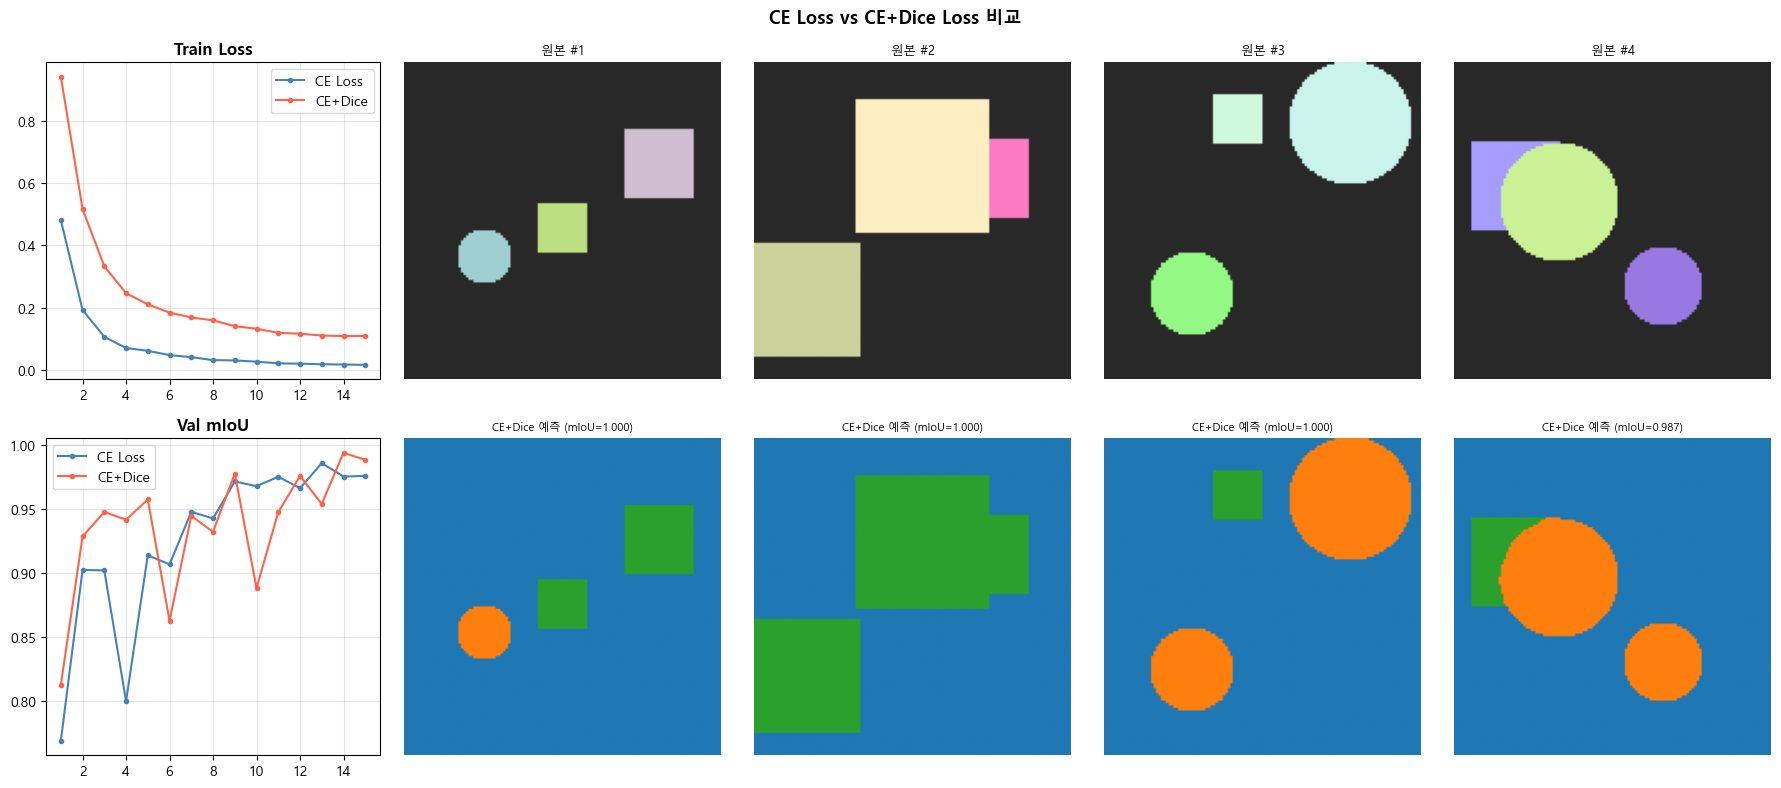

최종 CE mIoU:       0.9758
최종 CE+Dice mIoU:  0.9883


In [15]:
# ─────────────────────────────────────────────
# 4-2. 비교 시각화
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
epochs_r = range(1, 16)

# 학습 곡선 비교
for hist, name, color in [(hist_ce,'CE Loss','steelblue'), (hist_cd,'CE+Dice','tomato')]:
    axes[0][0].plot(epochs_r, hist["loss"], color=color, marker='o', markersize=3, label=name)
    axes[1][0].plot(epochs_r, hist["miou"], color=color, marker='o', markersize=3, label=name)

for ax, title in [(axes[0][0],"Train Loss"), (axes[1][0],"Val mIoU")]:
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)

# 예측 결과 비교
model_ce.eval(); model_cd.eval()
with torch.no_grad():
    for col in range(1,5):
        img_t, mask_t = val_ds[(col-1)*12]
        inp = img_t.unsqueeze(0).to(device)
        p_ce = model_ce(inp).argmax(1).squeeze().cpu()
        p_cd = model_cd(inp).argmax(1).squeeze().cpu()

        axes[0][col].imshow(img_t.permute(1,2,0).clamp(0,1))
        axes[0][col].set_title(f"원본 #{col}", fontsize=9); axes[0][col].axis('off')

        axes[1][col].imshow(p_cd.numpy(), cmap='tab10', vmin=0, vmax=9)
        axes[1][col].set_title(f"CE+Dice 예측 (mIoU={compute_miou(p_cd,mask_t):.3f})", fontsize=8)
        axes[1][col].axis('off')

plt.suptitle("CE Loss vs CE+Dice Loss 비교", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"최종 CE mIoU:       {hist_ce['miou'][-1]:.4f}")
print(f"최종 CE+Dice mIoU:  {hist_cd['miou'][-1]:.4f}")

---
## 🚀 도전 과제

### 과제 1. features 크기 확장
`features=[64,128,256,512]`로 더 큰 U-Net을 학습하고 mIoU를 비교하세요.

### 과제 2. 동기화 증강 구현
이미지와 마스크에 동일한 RandomHorizontalFlip을 적용하는 augmentation을 구현하세요.
```python
if random.random() > 0.5:
    img  = TF.hflip(img)   # 이미지 반전
    mask = TF.hflip(mask)  # 마스크도 동일하게!
```

### 과제 3. EarlyStopping 적용
Section 06에서 구현한 `EarlyStopping` 클래스를 U-Net 학습에 적용하고,  
최적 에포크에서 자동으로 학습을 종료하도록 만들어보세요.
